In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Setting a professional style for our "Discovery Lab"
plt.style.use('fivethirtyeight')
df = pd.read_excel("./01_Sales Dataset.xlsx")
print("Data successfully loaded for deep-dive discovery.")

Data successfully loaded for deep-dive discovery.


In [10]:
# This lists every column name in your file exactly as Python sees it
print(df.columns.tolist())

['Transaction_ID\n', 'Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City', 'Year-Month']


In [11]:
# 1. This removes the '\n' and any hidden spaces from your column names
df.columns = df.columns.str.strip().str.replace('\n', '', regex=False)

# 2. Now let's double-check it worked
print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['Transaction_ID', 'Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City', 'Year-Month']


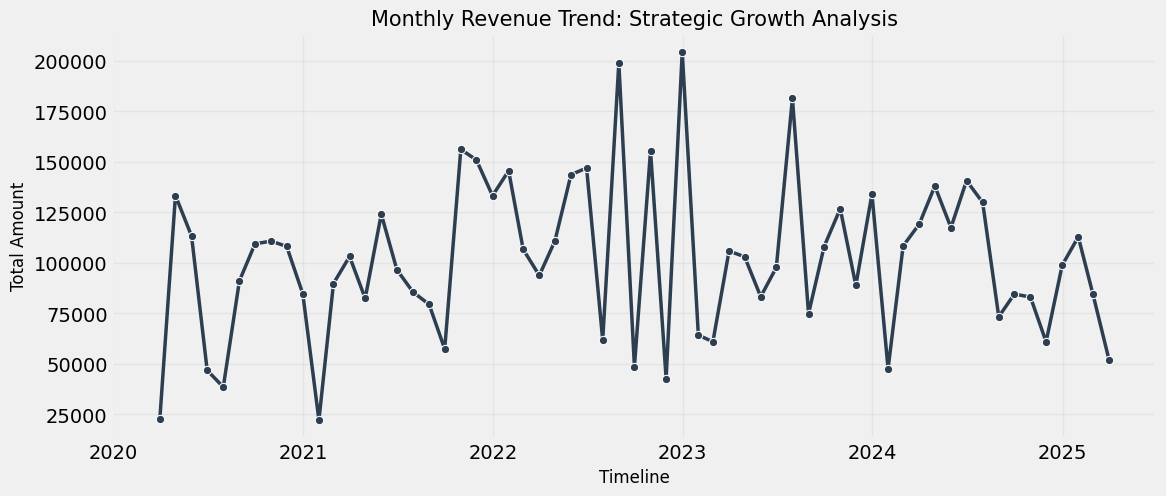

In [12]:
# 1. Convert to actual dates
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Group by Month and sum the Amount
monthly_trend = df.set_index('Order Date')['Amount'].resample('ME').sum()

# 3. Make the chart look beautiful
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_trend, marker='o', color='#2c3e50', linewidth=2.5)
plt.title('Monthly Revenue Trend: Strategic Growth Analysis', fontsize=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Total Amount', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Chart 2: Payment Mode Distribution
plt.figure(figsize=(8, 8))
df['PaymentMode'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Strategic Payment Channel Analysis', fontsize=14)
plt.ylabel('') # Removes the vertical 'PaymentMode' text
plt.show()

In [ ]:
# Chart 3: Profitability vs. Quantity by Category
category_data = df.groupby('Category')[['Profit', 'Quantity']].sum().sort_values(by='Profit', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Profit
sns.barplot(x=category_data.index, y=category_data['Profit'], ax=ax1, palette='viridis')
ax1.set_ylabel('Total Profit', color='b', fontsize=12)

# Line chart for Quantity on the same graph
ax2 = ax1.twinx()
sns.lineplot(x=category_data.index, y=category_data['Quantity'], ax=ax2, color='red', marker='o', linewidth=3)
ax2.set_ylabel('Quantity Sold', color='r', fontsize=12)

plt.title('Category Performance: Profit Margin vs. Sales Volume', fontsize=15)
plt.show()

In [ ]:
# Chart 4: Geographic Revenue Leaders (Top 10 Cities)
top_cities = df.groupby('City')['Amount'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_cities.plot(kind='barh', color='salmon')
plt.gca().invert_yaxis() # Puts the #1 city at the top
plt.title('Top 10 Revenue-Generating Cities', fontsize=15)
plt.xlabel('Total Revenue (Amount)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()